In [1]:
!pip install tensorflow

  Using cached flatbuffers-25.9.23-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached certifi-2025.10.5-py3-none-any.whl.metadata (2.5 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached werkzeug-3.1.3-py3-none-any.whl.metadata (3.7 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.7 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.7/200.7 MB 58.8 MB/s eta 0:00:0000:0100:01
   ━━━

In [2]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [7]:
!pip3 install pandas numpy matplotlib

  Using cached pandas-2.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached pandas-2.3.3-cp313-cp313-macosx_11_0_arm64.whl (10.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 51.3 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 17.3 MB/s eta 0:00:00
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]9 [matplotlib]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
X = df.iloc[:,3:13]
y = df.iloc[:,13]

In [11]:
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


In [12]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [13]:
geography = pd.get_dummies(X['Geography'], drop_first=True)
gender = pd.get_dummies(X['Gender'], drop_first=True)

In [14]:
X = X.drop(['Geography', 'Gender'], axis=1)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64
9996,516,35,10,57369.61,1,1,1,101699.77
9997,709,36,7,0.00,1,0,1,42085.58
9998,772,42,3,75075.31,2,1,0,92888.52


In [15]:
X = pd.concat([X, geography, gender], axis=1)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [19]:
!pip3 install scikit-learn

  Using cached scikit_learn-1.7.2-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp313-cp313-macosx_12_0_arm64.whl (8.6 MB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 58.2 MB/s eta 0:00:00a 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [20]:
# Train, test, split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_train

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]], shape=(8000, 11))

In [22]:
X_test = ss.transform(X_test)
X_test

array([[-0.57749609, -0.6557859 , -0.69539349, ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.29729735,  0.3900109 , -1.38944225, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.52560743,  0.48508334, -0.3483691 , ..., -0.57946723,
         1.73494238, -1.09499335],
       ...,
       [ 0.81311987,  0.77030065,  0.69270405, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.41876609, -0.94100321, -0.3483691 , ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.24540869,  0.00972116, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]], shape=(2000, 11))

Why fit_transform is used on X_train and and transform is on X_test is to avoid data leakage

In [23]:
X_train.shape

(8000, 11)

In [24]:
X_test.shape

(2000, 11)

In [25]:
### ANN implementation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ELU, PReLU, LeakyReLU, ReLU
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [26]:
model = Sequential()

In [27]:
# Adding the input layer
model.add(Dense(units=11, activation='relu'))

In [28]:
# Adding the first hidden layer

model.add(Dense(units=6, activation='relu'))

In [29]:
# Adding the second hidden layer

model.add(Dense(units=7, activation='relu'))

In [30]:
# Adding the output layer

model.add(Dense(units=1, activation='sigmoid'))

In [31]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01)

In [32]:
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [33]:
import keras 

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [34]:
model_history = model.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=1000, callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step - accuracy: 0.8212 - loss: 0.4318 - val_accuracy: 0.8228 - val_loss: 0.4197
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - accuracy: 0.8309 - loss: 0.4009 - val_accuracy: 0.8338 - val_loss: 0.4025
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - accuracy: 0.8494 - loss: 0.3719 - val_accuracy: 0.8489 - val_loss: 0.3698
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 409us/step - accuracy: 0.8548 - loss: 0.3512 - val_accuracy: 0.8451 - val_loss: 0.3679
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - accuracy: 0.8597 - loss: 0.3459 - val_accuracy: 0.8451 - val_loss: 0.3649
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step - accuracy: 0.8600 - loss: 0.3436 - val_accuracy: 0.8512 - val_loss: 0.3638
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - accuracy: 0.8623 - loss: 0.3412 - val_accuracy: 0.8508 - val_loss: 0.3665
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - accuracy: 0.8627 -

In [35]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

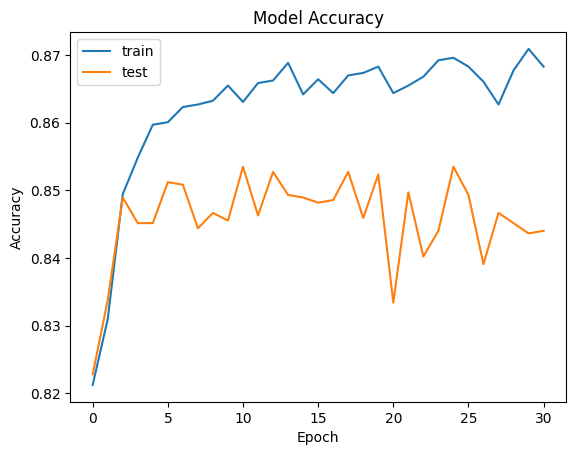

In [36]:
# Summarize hsitory of accuracy

plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

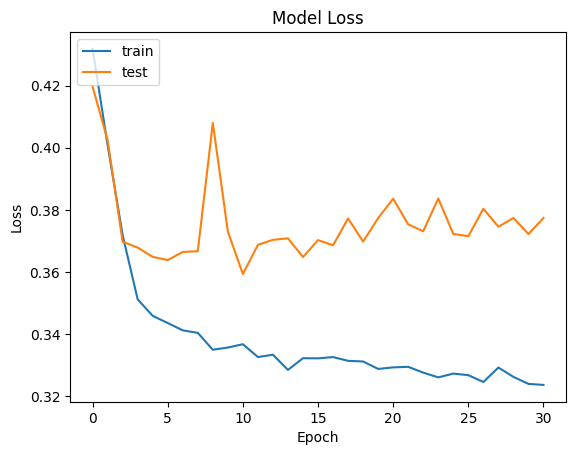

In [37]:
# Summarize hsitory of loss

plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [38]:
# Making the predictions and evaluating the model

# Predicting the test results

y_pred = model.predict(X_test)
y_pred = (y_pred> 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step


In [39]:
# Make the confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[1542,   65],
       [ 219,  174]])

In [40]:
# Calculating the accuracy

from sklearn.metrics import classification_report

cr = classification_report(y_pred, y_test)

In [41]:
print(cr)

              precision    recall  f1-score   support

       False       0.96      0.88      0.92      1761
        True       0.44      0.73      0.55       239

    accuracy                           0.86      2000
   macro avg       0.70      0.80      0.73      2000
weighted avg       0.90      0.86      0.87      2000



In [42]:
# You can get the weights of the model assigned while training but won't be of any use as you won't understand much
# Can save the weights tho

model.weights

[<Variable path=sequential/dense/kernel, shape=(11, 11), dtype=float32, value=[[ 0.4444538   0.01211563  0.19082545  0.06659955 -0.8196468  -0.10741281
    0.88477    -0.18966705  0.13896744 -0.6527621   0.7675332 ]
  [-1.3798982   0.9295777  -1.8816942  -2.7344174   1.3832797   0.548812
   -1.7231238  -3.20611    -1.9835072  -2.0115776   2.1864953 ]
  [-0.7755878   0.02836148 -0.49146992 -0.2953162   0.40195724  0.06056328
    0.34868762 -0.8450095   0.62082386  1.3243355   0.31142494]
  [ 0.3639099   1.1134561  -2.0077236   0.3905534   0.20932578 -1.2794226
   -1.3885118   0.3040293   0.3319348   0.7013241  -1.2854599 ]
  [-0.29708943  3.1999924   0.01920759 -0.9384429  -0.07079715 -4.425846
   -0.7077856  -0.17269439 -0.49308622  0.12923816 -1.2876109 ]
  [ 1.6548434   0.20425704 -1.3453733   1.0345255   0.06042552 -0.32506824
    0.43310478 -1.6479119  -0.9662931   1.1099442   0.28551707]
  [ 1.471928    0.3203186   0.08112472 -0.8686695   3.412209   -0.8583842
    0.22417969  0.55

## Qn) What are blackbox models and white box models?

### -> The models having very complex internal working which is not visually understandable are called as blackbox models. Examples are: Random Forest(100s of trees), ANN, XGBoost

### -> Whereas on the other hand if if you can visually understand the mathematics of the algorithm they are called as white box models. Eg: Decision Tree, Linear regression, Logistic Rgeression etc.